In [ ]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import h5py
import csv
import math
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation

dir = '/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/2th/mesh256/'
dirn = '/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/exa/'
#dirm='/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/cg1-T01-rho1-cen-128-1000st/'
dirm='/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/prdc/'


#data01,data02,data03,data04,data05,data06,data07,data08 = np.loadtxt(dir+'phi00002.dat', delimiter=',', unpack=True)
#plt.plot(data01,data06,marker="o",color='red', linewidth = 1)  
#plt.show()

#data = pd.read_csv(dir+'phi00100.csv')
#lux = data['LUX'].astype('int64')
#data = data.sort_values(by="LUX", ascending=True)
#log_data = np.log(data)
#data

In [74]:
dir1  = '/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/2th/mesh064/'
dir2  = '/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/2th/mesh128/'
dir3  = '/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/2th/mesh256/'
dir4  = '/Users/maeda/Desktop/Dropbox/analysis/telegraph-test-1D-1/2th/mesh512/'

i=100
aata01,aata02,aata03,aata04,aata05 = np.loadtxt(dir1+'phi'+"%05.f"%(i)+'.dat', delimiter=',', unpack=True)
eata01,eata02,eata03,eata04,eata05 = np.loadtxt(dir2+'phi'+"%05.f"%(i)+'.dat', delimiter=',', unpack=True)
fata01,fata02,fata03,fata04,fata05 = np.loadtxt(dir3+'phi'+"%05.f"%(i)+'.dat', delimiter=',', unpack=True)
gata01,gata02,gata03,gata04,gata05 = np.loadtxt(dir4+'phi'+"%05.f"%(i)+'.dat', delimiter=',', unpack=True)

array([-2.74485867,  0.68564861])

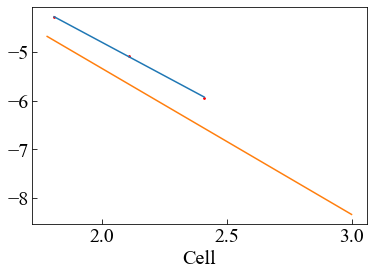

In [78]:
err1=aata02-aata04
err2=eata02-eata04
err3=fata02 -fata04
err4=gata02-gata04

err1=np.sqrt(np.mean(err1*err1))
err2=np.sqrt(np.mean(err2*err2))
err3=np.sqrt(np.mean(err3*err3))
err4=np.sqrt(np.mean(err4*err4))


musclerr=[0] * 4
msh=[0] * 4

musclerr[0]=err1
musclerr[1]=err2
musclerr[2]=err3
musclerr[3]=err4


msh[0]=64.0
msh[1]=128.0
msh[2]=256.0
msh[3]=512.0

fig = plt.figure()
ax = fig.add_subplot(111)

plt.rcParams["font.family"] = "Times New Roman"      #全体のフォントを設定
plt.rcParams["xtick.direction"] = "in"               #x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams["ytick.direction"] = "in"               #y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
#plt.rcParams["xtick.minor.visible"] = True          #x軸補助目盛りの追加
#plt.rcParams["ytick.minor.visible"] = True          #y軸補助目盛りの追加
#plt.rcParams["xtick.major.width"] = 1.5              #x軸主目盛り線の線幅
#plt.rcParams["ytick.major.width"] = 1.5              #y軸主目盛り線の線幅
#plt.rcParams["xtick.minor.width"] = 1.0              #x軸補助目盛り線の線幅
#plt.rcParams["ytick.minor.width"] = 1.0              #y軸補助目盛り線の線幅
plt.rcParams["xtick.major.size"] = 5                #x軸主目盛り線の長さ
plt.rcParams["ytick.major.size"] = 5                #y軸主目盛り線の長さ
#plt.rcParams["xtick.minor.size"] = 5                #x軸補助目盛り線の長さ
#plt.rcParams["ytick.minor.size"] = 5                #y軸補助目盛り線の長さ
plt.rcParams["font.size"] = 20                       #フォントの大きさ
#plt.rcParams["axes.linewidth"] = 1.5                 #囲みの太さ

lgmusclerr=np.log10(musclerr)
lgmsh=np.log10(msh)

plt.scatter(lgmsh, lgmusclerr, s=3.0,c='red')
lgmsh[0]

coef_20 = np.polyfit(lgmsh,lgmusclerr,1) #係数
y_pred_20 = coef_20[0]*lgmsh+ coef_20[1] #フィッティング関数
plt.plot(lgmsh,y_pred_20,label="d=1") #1次式


ax.set_xlabel('Cell')

x = np.arange(60, 1000, 0.1)
x=np.log10(x)
y = -(x) * 3.0 + 0.65726
plt.plot(x, y)


# 保存するPDFファイル名
pp = PdfPages('/Users/maeda/Desktop/err2.pdf')
# 画像をPDFとして保存する
pp.savefig(fig)
# PDFの保存終了
pp.close()
#plt.savefig("R-Vesc.png")
                    
#plt.savefig("R-Vesc.png")

coef_20




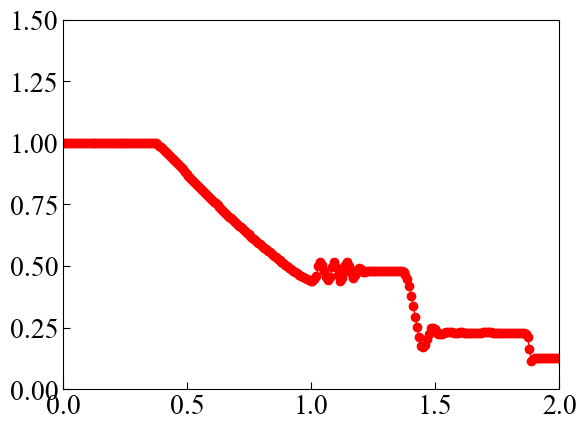

In [28]:
# coding: UTF-8
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import ArtistAnimation

dir = '/Users/maedarn/Dropbox/analysis/test1D/riemann/'

itime = 1
ftime = 6+1
tjump=1

fig = plt.figure()
#ax = fig.add_subplot(1, 1, 1)

image_list = []
for i in range(itime,ftime +1,tjump):
    file = open(dir+'title'+"%03.f"%(i)+'.dat')
    x,Rho,Vx,Vy,Vz,P,Bx,By,Bz = np.loadtxt(dir+'title'+"%03.f"%(i)+'.dat', unpack=True)
    plt.ylim([0, 1.5])
    plt.xlim([0, 2])
    image = plt.plot(x,Rho,marker="o",color='red', linewidth = 1) 
    image_list.extend([image])
    

# アニメーションを作成
ani = animation.ArtistAnimation(fig, image_list, interval=50, blit=True,repeat_delay=1000)
ani.save('/Users/maedarn/Desktop/riemanntest.mp4', writer="ffmpeg")
plt.show()



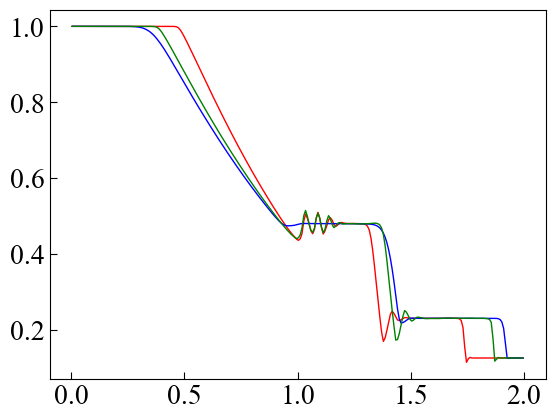

In [19]:
dir = '/Users/maedarn/Dropbox/analysis/test1D/riemann/'

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
#data01,data02,data03,data04,data05,data06,data07,data08,data09 = np.loadtxt(dir+'v-al/title003.dat', unpack=True)
data01,data02,data03,data04,data05,data06,data07,data08,data09 = np.loadtxt(dir+'title006.dat', unpack=True)
data11,data12,data13,data14,data15,data16,data17,data18,data19 = np.loadtxt(dir+'minm/title004.dat', unpack=True)
data21,data22,data23,data24,data25,data26,data27,data28,data29 = np.loadtxt(dir+'superbee/title004.dat', unpack=True)
data31,data32,data33,data34,data35,data36,data37,data38,data39 = np.loadtxt(dir+'vanleer/title004.dat', unpack=True)
#adata01,adata02,adata03,adata04,adata05,adata06,adata07 = np.loadtxt(dir+'ariemanndata0003.dat', unpack=True)
rho0=np.max(data02)
v0=np.max(data03)
p0=np.max(data05)

#arho0=np.max(adata02)
#av0=np.max(adata03)
#ap0=np.max(adata04)

#plt.plot(data01,data02,marker="o",color='red', linewidth = 1) 
plt.plot(data01,data02,color='red', linewidth = 1) 
plt.plot(data11,data12,color='blue', linewidth = 1) 
plt.plot(data21,data22,color='green', linewidth = 1) 
#plt.plot(data31,data32,color='black', linewidth = 1) 
#plt.plot(data01,data04/p0*1.2,marker="o",color='green', linewidth = 1) 
#print(data02,adata02)

#plt.plot(data01,adata02,marker="o",color='black', linewidth = 1) 
#plt.plot(data01,adata03,marker="o",color='cyan', linewidth = 1) 
#plt.plot(data01,adata04/ap0*1.2,marker="o",color='orange', linewidth = 1) 